In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import KNNImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, RFE, SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split


from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

import xgboost as xgb

from ctgan import CTGAN

import os


datadir = "data"
def get_training_data():
    x_train_orig = pd.read_csv(os.path.join(datadir, 'X_train.csv'))
    y_train_orig = pd.read_csv(os.path.join(datadir, 'y_train.csv'))

    x_train = x_train_orig.drop(columns=x_train_orig.columns[0]).to_numpy()
    y_train = y_train_orig.drop(columns=y_train_orig.columns[0]).to_numpy()
    return x_train, y_train

def get_test_data():
    x_test_orig = pd.read_csv(os.path.join(datadir, 'X_test.csv'))
    x_test = x_test_orig.drop(columns=x_test_orig.columns[0]).to_numpy()
    return x_test

## 1. Imputers

### 1.1 AutoEncoder imputer

the performance was shit so i deleted its code

### 1.2 KNN Imputer

In [4]:
import numpy as np
from sklearn.impute import KNNImputer

class KNNImputerWrapper:
    def __init__(self, n_neighbors=2):
        self.n_neighbors = n_neighbors
        self.imputer = KNNImputer(n_neighbors=self.n_neighbors)
        
    def fit(self, X_train, X_test=None):
        if X_test is not None:
            print('Fitting imputer on combined data')
            combined_data = np.vstack([X_train, X_test])
        else:
            print('Fitting imputer only on X_train')
            combined_data = X_train
        self.imputer.fit(combined_data)
        
    def transform(self, X):
        return self.imputer.transform(X)

### 1.3 Iterative Imputer

The code does not work, takes too long to run so i gave up but left the code for the acrhives 

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

class IterativeImputerWrapper:
    def __init__(self, max_iter=10, random_state=42):
        estimator = ExtraTreesRegressor(n_estimators=10, random_state=random_state, n_jobs=-1)
        self.imputer = IterativeImputer(estimator=estimator, max_iter=max_iter, random_state=random_state)
        
    def fit(self, X):
        self.imputer.fit(X)
        
    def transform(self, X):
        return self.imputer.transform(X)


### 1.4 Simple Imputer

Worked okay

In [6]:
from sklearn.impute import SimpleImputer

class SimpleImputerWrapper:
    def __init__(self, strategy='mean'):
        """
        Wrapper for sklearn's SimpleImputer.
        
        Parameters:
        - strategy: The imputation strategy ('mean', 'median', 'most_frequent', 'constant').
        """
        self.strategy = strategy
        self.imputer = SimpleImputer(strategy=self.strategy)
        
    def fit(self, X):
        self.imputer.fit(X)
        
    def transform(self, X):
        return self.imputer.transform(X)


## 2. Outlier Detection

### 2.1 Using PCA

In [7]:

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

class OutlierDetector:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.scaler = None
        self.pca = None
        self.gmm = None
        self.inliers = None
        self.outlier_cluster = None
        
    def fit(self, X, plot=False):
        
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)

        self.pca = PCA(n_components=self.n_components)
        X_pca = self.pca.fit_transform(X_scaled)
        
        self.gmm = GaussianMixture(n_components=2, random_state=42)
        self.gmm.fit(X_pca)
        
        cluster_labels = self.gmm.predict(X_pca)
        
        counts = np.bincount(cluster_labels)
        self.outlier_cluster = np.argmin(counts)
        self.inliers = cluster_labels != self.outlier_cluster
        
        if plot:
            plt.figure(figsize=(8, 6))
            plt.scatter(X_pca[:, 0], X_pca[:, 1], c=self.inliers, cmap='coolwarm', alpha=0.5)
            plt.title('PCA Components with Outlier Detection')
            plt.xlabel('PCA Component 1')
            plt.ylabel('PCA Component 2')
            plt.show()
            
        print(f"Number of outliers detected: {np.sum(~self.inliers)}")
    
    def transform(self, X):
        
        return X[self.inliers]
    
    def get_inlier_mask(self):
        return self.inliers

### 2.2 Using PCA and Gaussian Model on test

In [8]:

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

class OutlierDetectorTest:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.pca = None
        self.gmm = None
        self.inliers = None
        self.outlier_cluster = None
        
    def fit(self, X, x_test ,plot=False):
        
        self.pca = PCA(n_components=self.n_components)
        X_pca = self.pca.fit_transform(X)
        X_test_pca = self.pca.transform(x_test)

        self.gmm = GaussianMixture(n_components=2, random_state=42)
        self.gmm.fit(X_pca)
        y_test = self.gmm.predict_proba(X_test_pca)
        
        
        self.threshold= np.min(y_test[:,1])
        
        y_pred = self.gmm.predict_proba(X_pca)
        y_pred = y_pred[:,1] > self.threshold

        counts = np.bincount(y_pred)
        self.outlier_cluster = np.argmin(counts)
        self.inliers = y_pred != self.outlier_cluster


        if plot:
            xlim = (min(np.min(X_pca[:, 0]), np.min(X_test_pca[:, 0])), max(np.max(X_pca[:, 0]), np.max(X_test_pca[:, 0])))
            ylim = (min(np.min(X_pca[:, 1]), np.min(X_test_pca[:, 1])), max(np.max(X_pca[:, 1]), np.max(X_test_pca[:, 1])))

            plt.scatter(X_pca[:, 0], X_pca[:, 1], c=self.inliers, cmap='coolwarm', alpha=0.5)
            plt.title('PCA Components with Outlier Detection')
            plt.xlabel('PCA Component 1')
            plt.ylabel('PCA Component 2')
            plt.xlim(xlim)
            plt.ylim(ylim)
            plt.show()
            plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], cmap='coolwarm', alpha=0.5)
            plt.title('PCA Components with Outlier Detection')
            plt.xlabel('PCA Component 1')
            plt.ylabel('PCA Component 2')
            plt.xlim(xlim)
            plt.ylim(ylim)
            plt.show()

            
            
        print(f"Number of outliers detected: {np.sum(~self.inliers)}")
    
    def transform(self, X):
        
        return X[self.inliers]
    
    def get_inlier_mask(self):
        return self.inliers

## 3. Feature selection

### 3.1 Variance Threshold

In [9]:
class VarianceThresholdSelector:
    def __init__(self, threshold=0.0):
        self.threshold = threshold
        self.selector = VarianceThreshold(threshold=self.threshold)
        
    def fit(self, X, y=None):
        self.selector.fit(X)
        
    def transform(self, X):
        return self.selector.transform(X)
        
    def get_support(self):
        return self.selector.get_support()


### 3.2 Univariate

In [10]:
class UnivariateSelector:
    def __init__(self, k=10):
        self.k = k
        self.selector = SelectKBest(score_func=f_regression, k=self.k)
        
    def fit(self, X, y):
        self.selector.fit(X, y)
        
    def transform(self, X):
        return self.selector.transform(X)
        
    def get_support(self):
        return self.selector.get_support()


### 3.3 RFE

This does not work, takes too long to run. Keeping the code for the archives though

In [11]:
class RFESelector:
    def __init__(self, estimator, n_features_to_select=10):
        self.estimator = estimator
        self.n_features_to_select = n_features_to_select
        self.selector = RFE(estimator=self.estimator, n_features_to_select=self.n_features_to_select)
        
    def fit(self, X, y):
        self.selector.fit(X, y)
        
    def transform(self, X):
        return self.selector.transform(X)
        
    def get_support(self):
        return self.selector.get_support()


### 3.4 Lasso

In [12]:

# Gio: saw that this lasso select only two features, really low (something is not working) 
class LassoSelector:
    def __init__(self, cv=5):
        self.cv = cv
        self.selector = None
        self.coef_threshold = 1e-5 
        
    def fit(self, X, y):
        lasso = LassoCV(cv=self.cv, n_jobs=-1)
        lasso.fit(X, y)
        self.selector = lasso
        print(f"coefficients: {self.selector.coef_}")  
        if np.all(np.abs(self.selector.coef_) <= self.coef_threshold):
            
            max_coef = np.max(np.abs(self.selector.coef_))
            self.coef_threshold = max_coef - 1e-8  
            print(f"Adjusted Lasso threshold to {self.coef_threshold} to select at least one feature")

        if np.all(np.abs(self.selector.coef_) >= self.coef_threshold):
            min_coef = np.min(np.abs(self.selector.coef_))
            self.coef_threshold = min_coef + 1e-8
            print(f"Adjusted Lasso threshold to {self.coef_threshold} to select some features ")
            
        
    def transform(self, X):
        mask = np.abs(self.selector.coef_) > self.coef_threshold
        if not np.any(mask):
            mask = np.abs(self.selector.coef_) == np.max(np.abs(self.selector.coef_))
            print("No features met the threshold. Selected the top feature based on coefficient.")
        return X[:, mask]
    def get_support(self):
        mask = np.abs(self.selector.coef_) > self.coef_threshold
        if not np.any(mask):
            mask = np.abs(self.selector.coef_) == np.max(np.abs(self.selector.coef_))
        return mask


### 3.5 Tree based approach (RandomForestRegressor)

Best working one

In [13]:
class TreeBasedSelector:
    def __init__(self, estimator=None, threshold="median"):
        if estimator is None:
            estimator = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        self.estimator = estimator
        self.threshold = threshold
        self.selector = None

    def fit(self, X, y):
        
        self.estimator.fit(X, y)
        
        if isinstance(self.threshold, str) and self.threshold.startswith("percentile_"):
            percentile_value = float(self.threshold.split("_")[1])
            threshold_value = np.percentile(self.estimator.feature_importances_, percentile_value)
            self.selector = SelectFromModel(self.estimator, threshold=threshold_value, prefit=True)
        else:
            self.selector = SelectFromModel(self.estimator, threshold=self.threshold, prefit=True)

    def transform(self, X):
        return self.selector.transform(X)
    
    def get_support(self):
        return self.selector.get_support()

### 3.6 Gradient Boosting for feature selection

works pretty well

In [14]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance

class GradientBoostingSelector:
    def __init__(
        self, 
        estimator=None, 
        threshold="median", 
        learning_rate=0.1, 
        max_iter=100, 
        max_leaf_nodes=31, 
        random_state=42, 
        n_repeats=7
    ):

        if estimator is None:
            self.estimator = HistGradientBoostingRegressor(
                learning_rate=learning_rate,
                max_iter=max_iter,
                max_leaf_nodes=max_leaf_nodes,
                random_state=random_state
            )
        else:
            self.estimator = estimator
        self.threshold = threshold
        self.n_repeats = n_repeats
        self.random_state = random_state
        self.selector = None
        self.importances_ = None

    def fit(self, X, y):
        
        self.estimator.fit(X, y)
        
        perm_importance = permutation_importance(
            self.estimator, X, y, n_repeats=self.n_repeats, random_state=self.random_state
        )
        self.importances_ = perm_importance.importances_mean
        
        if isinstance(self.threshold, str) and self.threshold.startswith("percentile_"):
            percentile_value = float(self.threshold.split("_")[1])
            threshold_value = np.percentile(self.importances_, percentile_value)
        elif isinstance(self.threshold, str):
            if self.threshold == "median":
                threshold_value = np.median(self.importances_)
            elif self.threshold == "mean":
                threshold_value = np.mean(self.importances_)
            else:
                raise ValueError(f"Unknown string threshold: {self.threshold}")
        else:
            threshold_value = self.threshold  
        

        self.selector = SelectFromModel(
            estimator=self.estimator,
            threshold=threshold_value,
            prefit=True,
            importance_getter=lambda estimator: self.importances_
        )

    def transform(self, X):
        return self.selector.transform(X)

    def get_support(self):
        return self.selector.get_support()

    @property
    def feature_importances_(self):
        return self.importances_


### 3.7 Lasso the second

In [15]:

class LassoSelectorTheSecond:
    def __init__(self, alpha=0.5,threshold=1e-4):
        self.selector = None
        self.alpha = alpha  
        self.threshold = threshold
        
    def fit(self, X, y):
        from sklearn.linear_model import Lasso
        self.selector  = Lasso(alpha=self.alpha)
        self.selector.fit(X, y)

            
        
    def transform(self, X):
        mask = np.abs(self.selector.coef_) > self.threshold
        if not np.any(mask):
            mask = np.abs(self.selector.coef_) == np.max(np.abs(self.selector.coef_))
            print("No features met the threshold. Selected the top feature based on coefficient.")
        return X[:, mask]

    def get_support(self):
        mask = np.abs(self.selector.coef_) > self.threshold
        if not np.any(mask):
            mask = np.abs(self.selector.coef_) == np.max(np.abs(self.selector.coef_))
        return mask


## 4. Models

### 4.1 Random Forest

Works great, but not quite as much as I would like it to

In [16]:
from sklearn.ensemble import RandomForestRegressor

class RandomForestModel:
    def __init__(self, params=None):
        
        default_params = {'n_estimators': 100, 'random_state': 42}
        if params:
            default_params.update(params)
        
        self.model = RandomForestRegressor(**default_params, n_jobs=-1)

    def train(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


### 4.2 XGBoost

Best performing non-ensemble model so far, on which i then did hyperparameter optimisation to get my best possible score

In [17]:
class XGBoostModel:
    def __init__(self, params=None):
        """
        Initializes the XGBoost model with given parameters.
        
        Parameters:
        - params (dict): Dictionary of XGBoost parameters.
        """
        if params is None:
            # chosen since std dev in cross-validation
            params = {
                'colsample_bytree': 0.832459150412013,
                'gamma': 0.4438520913791499,
                'learning_rate': 0.08018300251041574,
                'max_depth': 5,
                'n_estimators': 338,
                'reg_alpha': 0.14299168205283586,
                'reg_lambda': 3.2845318951524165,
                'subsample': 0.8854654189948783,
                'random_state': 42,
                'n_jobs': -1
            }
        self.model = xgb.XGBRegressor(**params)
    
    def train(self, X, y):
        self.model.fit(X, y)
    
    def predict(self, X):
        return self.model.predict(X)


### 4.3 Support Vector Regression

In [18]:
from sklearn.svm import SVR

class SVRModel:
    def __init__(self, kernel='rbf', C=1.0, epsilon=0.1):
        self.model = SVR(kernel=kernel, C=C, epsilon=epsilon)

    def train(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


### 4.4 Kernel Ridge Regression

In [19]:
from sklearn.kernel_ridge import KernelRidge

class KernelRidgeModel:
    def __init__(self, kernel='rbf', alpha=1.0, gamma=None):
        self.model = KernelRidge(kernel=kernel, alpha=alpha, gamma=gamma)

    def train(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


### 4.5 Gaussian Process

In [20]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

class GaussianProcessModel:
    def __init__(self, kernel=None, alpha=1e-10, normalize_y=True, random_state=42):
        if kernel is None:
            kernel = C(1.0) * RBF(length_scale=1.0)
        self.model = GaussianProcessRegressor(kernel=kernel, alpha=alpha, normalize_y=normalize_y, random_state=random_state)

    def train(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


### 4.6 Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression

class LinearRegressionModel:
    def __init__(self):
        self.model = LinearRegression()

    def train(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


### 4.7 MLP regressor

Works really bad

In [22]:
from sklearn.neural_network import MLPRegressor

class MLPRegressorModel:
    def __init__(self, hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=200, random_state=42):
        self.model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, activation=activation,
                                  solver=solver, max_iter=max_iter, random_state=random_state)

    def train(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


### 4.8 Neural Net

In [23]:
class NeuralNetworkModel(nn.Module):
    def __init__(self, input_dim, layers=[256, 128, 64], dropout=0.2):
        super().__init__()
        layer_list = []
        prev_dim = input_dim
        for layer_dim in layers:
            layer_list.append(nn.Linear(prev_dim, layer_dim))
            layer_list.append(nn.ReLU())
            if dropout > 0:
                layer_list.append(nn.Dropout(dropout))
            prev_dim = layer_dim
        layer_list.append(nn.Linear(prev_dim, 1))  # Regression output
        self.network = nn.Sequential(*layer_list)
        
    def forward(self, x):
        return self.network(x).squeeze()


below are my ensembling models

### 4.10 XGBoost Ensemble

best overall

In [24]:
class XGBoostEnsemble:
    def __init__(self, param_sets):

        self.models = [xgb.XGBRegressor(**params) for params in param_sets]
    
    def train(self, X, y):

        for i, model in enumerate(self.models):
            print(f"Training model {i+1}/{len(self.models)} in ensemble")
            model.fit(X, y)
    
    def predict(self, X):

        predictions = np.array([model.predict(X) for model in self.models])
        return np.mean(predictions, axis=0)


### 4.11 Mixed Ensemble

mixing my previous best indivdual models (XGBoost + RandomForest), not convincing 

In [25]:
class MixedEnsemble:
    def __init__(self, xgb_param_sets, rf_param_sets):

        self.models = []
        
        for params in xgb_param_sets:
            xgb_model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
            self.models.append(xgb_model)
        
        for params in rf_param_sets:
            rf_model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
            self.models.append(rf_model)
    
    def train(self, X, y):

        for model in self.models:
            model.fit(X, y)
    
    def predict(self, X):

        predictions = np.array([model.predict(X) for model in self.models])
        return np.mean(predictions, axis=0)

### 4.12 HistGradientBoosting Ensemble

Second best model overall, may be improved with further parameter tuning

In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

class HistGradientBoostingEnsemble:
    def __init__(self, param_sets):

        self.models = [HistGradientBoostingRegressor(**params) for params in param_sets]
    
    def train(self, X, y):

        for i, model in enumerate(self.models):
            print(f"Training HistGradientBoosting model {i+1}/{len(self.models)} in ensemble")
            model.fit(X, y)
    
    def predict(self, X):

        predictions = np.array([model.predict(X) for model in self.models])
        return np.median(predictions, axis=0)


# Pipeline Execution

## Utils


In [40]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_age_prediction_boxplot(ages, predictions):
    """
    Function to create a boxplot of actual ages vs predicted ages.
    
    Parameters:
    ages (list or numpy array): Array of actual ages.
    predictions (list or numpy array): Array of predicted ages.
    
    Returns:
    None: Displays the boxplot.
    """
    # Convert inputs to numpy arrays if they aren't already
    ages = ages.flatten()
    predictions = predictions.flatten()

    # Get unique ages
    unique_ages = np.unique(ages)

    # Create lists for boxplot representation
    ages_list = []
    prediction_values = []

    for age in unique_ages:
        print(age)
        # Get all predictions corresponding to the current age
        age_predictions = predictions[ages == age]
        
        # Append the age multiple times for boxplotting
        ages_list.extend([age] * len(age_predictions))
        prediction_values.extend(age_predictions)

    # Plotting the boxplot
    plt.figure(figsize=(14, 8))
    sns.boxplot(x=ages_list, y=prediction_values)
    plt.xlabel('Age')
    plt.ylabel('Predicted Age')
    plt.title('Boxplot of Actual Age vs Predicted Age Dispersion')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


## processing


Current config

In [27]:
ensemble_xgb_top_params = [{'colsample_bytree': 0.9601644943224169, 'gamma': 0.17707333539656273, 'learning_rate': 0.0894327665008165, 'max_depth': 4, 'n_estimators': 218, 'reg_alpha': 0.37728416310462265, 'reg_lambda': 1.060213593333179, 'subsample': 0.7966237496749534}, {'colsample_bytree': 0.7194676741326944, 'gamma': 0.12695770696717235, 'learning_rate': 0.05937521256772024, 'max_depth': 5, 'n_estimators': 486, 'reg_alpha': 0.30087830981676966, 'reg_lambda': 1.8545214831324028, 'subsample': 0.7110660842063597}, {'colsample_bytree': 0.9242412814401268, 'gamma': 0.01834160144529895, 'learning_rate': 0.06048738886880416, 'max_depth': 6, 'n_estimators': 210, 'reg_alpha': 0.8444406726336288, 'reg_lambda': 3.248848696025762, 'subsample': 0.7091416458200782}, {'colsample_bytree': 0.832459150412013, 'gamma': 0.4438520913791499, 'learning_rate': 0.08018300251041574, 'max_depth': 5, 'n_estimators': 338, 'reg_alpha': 0.14299168205283586, 'reg_lambda': 3.2845318951524165, 'subsample': 0.8854654189948783}, {'colsample_bytree': 0.8454489914076949, 'gamma': 0.34621801644513517, 'learning_rate': 0.0638824667597043, 'max_depth': 6, 'n_estimators': 473, 'reg_alpha': 0.21876421957307024, 'reg_lambda': 2.6743060060520234, 'subsample': 0.8211508513174122}]

#ensemble_xgb_top_params = [{'colsample_bytree': 0.8428632090367042, 'gamma': 0.4156857450312506, 'learning_rate': 0.07155544795420989, 'max_depth': 4, 'n_estimators': 153, 'reg_alpha': 0.967973765439823, 'reg_lambda': 1.2652246700969396, 'subsample': 0.9375453518408898}, {'colsample_bytree': 0.7305347417861211, 'gamma': 0.07642956959216601, 'learning_rate': 0.05919154567690163, 'max_depth': 7, 'n_estimators': 449, 'reg_alpha': 0.18656702405130576, 'reg_lambda': 1.8552855060815414, 'subsample': 0.7520120785884264}, {'colsample_bytree': 0.9260134555776824, 'gamma': 0.18812979276545788, 'learning_rate': 0.02670014333973375, 'max_depth': 8, 'n_estimators': 463, 'reg_alpha': 0.558404249735805, 'reg_lambda': 2.2726660277409287, 'subsample': 0.9719063155284207}]


#ensemble_xgb_top_params = [
#    {'colsample_bytree': 0.8428632090367042, 'gamma': 0.4156857450312506, 'learning_rate': 0.07155544795420989, 'max_depth': 4, 'n_estimators': 153, 'reg_alpha': 0.967973765439823, 'reg_lambda': 1.2652246700969396, 'subsample': 0.9375453518408898},
#    {'colsample_bytree': 0.9798185450062039, 'gamma': 0.4330319447502042, 'learning_rate': 0.019043734021237883, 'max_depth': 4, 'n_estimators': 473, 'reg_alpha': 0.8105533307818329, 'reg_lambda': 3.9618283879448333, 'subsample': 0.7451250673310584},
#    {'colsample_bytree': 0.9798185450062039, 'gamma': 0.4330319447502042, 'learning_rate': 0.019043734021237883, 'max_depth': 4, 'n_estimators': 473, 'reg_alpha': 0.8105533307818329, 'reg_lambda': 3.9618283879448333, 'subsample': 0.7451250673310584},  
#    {'colsample_bytree': 0.8428632090367042, 'gamma': 0.4156857450312506, 'learning_rate': 0.07155544795420989, 'max_depth': 4, 'n_estimators': 153, 'reg_alpha': 0.967973765439823, 'reg_lambda': 1.2652246700969396, 'subsample': 0.9375453518408898},  
#    {'colsample_bytree': 0.715547061046728, 'gamma': 0.1683021390969603, 'learning_rate': 0.03688293538779485, 'max_depth': 5, 'n_estimators': 271, 'reg_alpha': 0.20173046233023584, 'reg_lambda': 3.0537146436395, 'subsample': 0.726360433372797},
#    {'colsample_bytree': 0.832459150412013, 'gamma': 0.4438520913791499, 'learning_rate': 0.08018300251041574, 'max_depth': 5, 'n_estimators': 338, 'reg_alpha': 0.14299168205283586, 'reg_lambda': 3.2845318951524165, 'subsample': 0.8854654189948783},
#    {'colsample_bytree': 0.7576867056426012, 'gamma': 0.02043430813323943, 'learning_rate': 0.043787012614432914, 'max_depth': 7, 'n_estimators': 269, 'reg_alpha': 0.17701048427674682, 'reg_lambda': 1.266107601271167, 'subsample': 0.7361907613301802},  
#    {'colsample_bytree': 0.8900202562950177, 'gamma': 0.12007280938909654, 'learning_rate': 0.025172665621732787, 'max_depth': 4, 'n_estimators': 250, 'reg_alpha': 0.12804583895777244, 'reg_lambda': 1.455708080536883, 'subsample': 0.741648151794823},  
#    {'colsample_bytree': 0.8990505307324167, 'gamma': 0.0025307919231093434, 'learning_rate': 0.04216161028349973, 'max_depth': 5, 'n_estimators': 293, 'reg_alpha': 0.6918951976926933, 'reg_lambda': 2.9558837785078014, 'subsample': 0.7672807928381679},  
#    {'colsample_bytree': 0.8727773725774253, 'gamma': 0.3658238776498201, 'learning_rate': 0.03553794588449312, 'max_depth': 4, 'n_estimators': 195, 'reg_alpha': 0.34080354025301784, 'reg_lambda': 3.792271976810694, 'subsample': 0.9575238255529035},  
#    {'colsample_bytree': 0.7880464524154114, 'gamma': 0.007039911357542228, 'learning_rate': 0.049768480817761036, 'max_depth': 6, 'n_estimators': 388, 'reg_alpha': 0.6059599747810114, 'reg_lambda': 3.778902635540047, 'subsample': 0.8953231076505833},  
#    {'colsample_bytree': 0.882869300193969, 'gamma': 0.25133951161443074, 'learning_rate': 0.02029575024999787, 'max_depth': 8, 'n_estimators': 323, 'reg_alpha': 0.9082658859666537, 'reg_lambda': 1.7186856720009174, 'subsample': 0.7434684616273669},  
#    {'colsample_bytree': 0.7230939729486379, 'gamma': 0.144875726456884, 'learning_rate': 0.04224425745080089, 'max_depth': 5, 'n_estimators': 269, 'reg_alpha': 0.808120379564417, 'reg_lambda': 2.9002112695312703, 'subsample': 0.9614381770563152},  
#    {'colsample_bytree': 0.7194676741326944, 'gamma': 0.12695770696717235, 'learning_rate': 0.05937521256772024, 'max_depth': 5, 'n_estimators': 486, 'reg_alpha': 0.30087830981676966, 'reg_lambda': 1.8545214831324028, 'subsample': 0.7110660842063597},  
#    {'colsample_bytree': 0.7305347417861211, 'gamma': 0.07642956959216601, 'learning_rate': 0.05919154567690163, 'max_depth': 7, 'n_estimators': 449, 'reg_alpha': 0.18656702405130576, 'reg_lambda': 1.8552855060815414, 'subsample': 0.7520120785884264}, 
#    {'colsample_bytree': 0.8454489914076949, 'gamma': 0.34621801644513517, 'learning_rate': 0.0638824667597043, 'max_depth': 6, 'n_estimators': 473, 'reg_alpha': 0.21876421957307024, 'reg_lambda': 2.6743060060520234, 'subsample': 0.8211508513174122},
#    {'colsample_bytree': 0.9260134555776824, 'gamma': 0.18812979276545788, 'learning_rate': 0.02670014333973375, 'max_depth': 8, 'n_estimators': 463, 'reg_alpha': 0.558404249735805, 'reg_lambda': 2.2726660277409287, 'subsample': 0.9719063155284207},
#    {'colsample_bytree': 0.7839937280980852, 'gamma': 0.38474646659596845, 'learning_rate': 0.047408749711504675, 'max_depth': 9, 'n_estimators': 423, 'reg_alpha': 0.4254364386164168, 'reg_lambda': 2.522831136053365, 'subsample': 0.772722919724524},
#    {'colsample_bytree': 0.7254513142255575, 'gamma': 0.4933197892505877, 'learning_rate': 0.08485415915122406, 'max_depth': 4, 'n_estimators': 441, 'reg_alpha': 0.8127995672575026, 'reg_lambda': 3.841745732151576, 'subsample': 0.9958003191468612},
#    {'colsample_bytree': 0.8156249507619748, 'gamma': 0.007983126110107097, 'learning_rate': 0.056178765124429805, 'max_depth': 7, 'n_estimators': 466, 'reg_alpha': 0.6832635188254582, 'reg_lambda': 2.8299899733478626, 'subsample': 0.9499584735208493},
 #   {'colsample_bytree': 0.9242412814401268, 'gamma': 0.01834160144529895, 'learning_rate': 0.06048738886880416, 'max_depth': 6, 'n_estimators': 210, 'reg_alpha': 0.8444406726336288, 'reg_lambda': 3.248848696025762, 'subsample': 0.7091416458200782},
#    {'colsample_bytree': 0.9601644943224169, 'gamma': 0.17707333539656273, 'learning_rate': 0.0894327665008165, 'max_depth': 4, 'n_estimators': 218, 'reg_alpha': 0.37728416310462265, 'reg_lambda': 1.060213593333179, 'subsample': 0.7966237496749534}
#]


ensemble_rf_param_sets = [
    {'n_estimators': 250, 'max_depth': None, 'min_samples_split': 4},
]


histgb_param_sets = [
    {
        'learning_rate': 0.1,
        'max_iter': 100,
        'max_depth': 10,
        'min_samples_leaf': 20,
        'max_bins': 255,
        'random_state': 42
    },
    {
        'learning_rate': 0.05,
        'max_iter': 200,
        'max_depth': 8,
        'min_samples_leaf': 30,
        'max_bins': 200,
        'random_state': 42
    },
    {
        'learning_rate': 0.2,
        'max_iter': 50,
        'max_depth': 12,
        'min_samples_leaf': 10,
        'max_bins': 255,
        'random_state': 42
    }
]


Below I am defining the instances of the models available in the pipeline

In [28]:
imputers = {
    #'Autoencoder': AutoencoderImputer(input_dim=X_train.shape[1], test_as_val=False),
    'KNN': KNNImputerWrapper(n_neighbors=2),
    'Iterative': IterativeImputerWrapper(),
    #'SimpleMedian': SimpleImputerWrapper(strategy='median'),
    #'MissForest': MissForestImputer(),
}


feature_selectors = {
    'VarianceThreshold': VarianceThresholdSelector(threshold=0.0),
    'Univariate': UnivariateSelector(k=10),
    #'RFE': RFESelector(estimator=RandomForestRegressor(n_estimators=100, random_state=42), n_features_to_select=10),
    'Lasso': LassoSelectorTheSecond(),
    'TreeBased': TreeBasedSelector(estimator=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), threshold="mean"),
    #'GradientBoosting': GradientBoostingSelector(threshold="percentile_90", learning_rate=0.05, max_iter=150, max_leaf_nodes=15)
}


outlier_detectors = {
    'PCAGaussian': OutlierDetector(n_components=2),
    'PCAGaussianTest' : OutlierDetectorTest(n_components=2)
}

models = {
    'RandomForest': RandomForestModel(),
    'XGBoost': XGBoostModel(),
    # 'TabNet': TabNetModel(),
    'XGBoostEnsemble': XGBoostEnsemble(ensemble_xgb_top_params),
    'MixedEnsemble': MixedEnsemble(ensemble_xgb_top_params, ensemble_rf_param_sets),
    'HistGradientBoostingEnsemble': HistGradientBoostingEnsemble(param_sets=histgb_param_sets),
    #'SVR': SVRModel(),
    #'KernelRidge': KernelRidgeModel(),
    #'GaussianProcess': GaussianProcessModel(),
    #'LinearRegression': LinearRegressionModel(),
    #'MLPRegressor': MLPRegressorModel(),
    #'NeuralNetwork': NeuralNetworkModel(input_dim=X_train.shape[1], layers=[256, 128, 64], dropout=0.2)
}


In [77]:
def run_pipeline(imputer_name, outlierDetetor ,feature_selector_names, model_name, submission_filename='submission.csv',  train_full=False, split_seed=1,y_scale=True):


    print(f"\n=== Running Pipeline with:")
    print(f"Imputer: {imputer_name}")
    print(f"Feature Selector: {feature_selector_names}")
    print(f"Model: {model_name}")
    print(f"Train on full dataset: {train_full} ===\n")
    
    # Step 0: Load Data
    X_train , y_train = get_training_data()
    y_train = y_train
    X_test = get_test_data()
    
    # Step 1: Imputation
    imputer = imputers[imputer_name]

    if imputer_name == 'KNN':
        imputer.fit(X_train, X_test) # fitting the KNN imputer on both train and test data, showed very slight performance increase
    else:
        imputer.fit(X_train)
    X_train = imputer.transform(X_train)
    
    X_test = imputer.transform(X_test)
    print("Imputation completed.")

    # Step 4: Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    print("Scaling completed.")

    y_scaler = StandardScaler()
    if y_scale:
        y_train = y_scaler.fit_transform(y_train)
        print("Target scaling completed.")
    
    
    # Step 2: Outlier Detection and Removal
    outlier_detector = outlier_detectors[outlierDetetor]
    if outlierDetetor == 'PCAGaussianTest':
        outlier_detector.fit(X_train, X_test,plot=True)
    else:
        outlier_detector.fit(X_train, plot=False)
    X_train = outlier_detector.transform(X_train)
    print(y_train.shape)
    y_train = y_train[outlier_detector.get_inlier_mask()]
    print(y_train.shape)
    print(f"Outlier removal completed. Number of inliers: {len(y_train)}")
    
   
    
    # Step 3: Feature Selection
    if type(feature_selector_names) == str:
        feature_selector_names = [feature_selector_names]
    

    supports = None
    for feature_selector_name in feature_selector_names: 
        feature_selector = feature_selectors[feature_selector_name]
        feature_selector.fit(X_train, y_train)
        if supports is None:
            supports = feature_selector.get_support()
        np.logical_or(supports, feature_selector.get_support(), out=supports)


    # X_train = X_train[:, supports]
    # X_test = X_test[:, supports]

    print(f"Feature selection completed. Number of selected features: {X_train.shape[1]}")


    
    # Check if at least one feature is selected
    if X_train.shape[1] == 0:
        print("No features selected. Skipping this pipeline run.")
        return None
    


    # Step 5: Model Training and Evaluation
    model = models[model_name]


    if train_full: 
        print(f"Training {model_name} on the entire dataset.")
        X_tr, y_tr = X_train, y_train
        X_val , y_val = X_train, y_train
    else:
        print(f"Performing train-validation split and training {model_name}.")
        X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=split_seed)

    model.train(X_tr[:,supports], y_tr)

    y_pred_train = model.predict(X_tr[:,supports])

    overfitting_model = models["RandomForest"]
    overfitting_model.train(X_tr,y_tr- y_pred_train.reshape(-1,1)) 

    y_pred = model.predict(X_val[:,supports]) + overfitting_model.predict(X_val)

    val_r2 = r2_score(y_val, y_pred)
    val_mae = mean_absolute_error(y_val, y_pred)
    val_mse = mean_squared_error(y_val, y_pred)
    print(f"Validation R^2 Score: {val_r2:.4f}, MAE: {val_mae:.4f}, MSE: {val_mse:.4f}")
    metrics = {
        'Imputer': imputer_name,
        'Feature Selector': feature_selector_names,
        'Model': model_name,
        'Validation R2': val_r2,
        'Validation MAE': val_mae,
        'Validation MSE': val_mse
    }
    
    if y_scale:
        y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1))
        y_train = y_scaler.inverse_transform(y_train)
    
    if train_full:
        plot_age_prediction_boxplot(y_train, y_pred)
    
    

    # Step 6: Prediction and Submission
    y_test_pred = model.predict(X_test[:,supports]) + overfitting_model.predict(X_test)
    if y_scale:
        y_test_pred = y_scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()


    submission = pd.DataFrame(y_test_pred, columns=['y'])
    submission.index.name = 'id'

    submission['y'] = submission['y'].clip(lower=10, upper=100) # clip predictions to [10, 100]
    
    submission.to_csv(submission_filename)
    print(f"Submission saved to {submission_filename}")

    return metrics


## Testing Example

For testing, set train_full=False below so I can see the performance on a validation set. Important to test with multiple split seeds though!!

In [79]:
metrics_full= run_pipeline(
    imputer_name='KNN',
    outlierDetetor='PCAGaussian',
    feature_selector_names=['TreeBased','Lasso'],
    model_name='XGBoostEnsemble',
    submission_filename='submission_baseline.csv',
    train_full=False,
    split_seed=1,
    y_scale=False
)
print(metrics_full)


=== Running Pipeline with:
Imputer: KNN
Feature Selector: ['TreeBased', 'Lasso']
Model: XGBoostEnsemble
Train on full dataset: False ===

Fitting imputer on combined data
Imputation completed.
Scaling completed.
Number of outliers detected: 67
(1212, 1)
(1145, 1)
Outlier removal completed. Number of inliers: 1145


/nix/store/bj5dqnlwb7501kj17lsisa4cns79y6ss-python3.11-scikit-learn-1.4.2/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Feature selection completed. Number of selected features: 81
Performing train-validation split and training XGBoostEnsemble.
Training model 1/5 in ensemble
Training model 2/5 in ensemble
Training model 3/5 in ensemble
Training model 4/5 in ensemble
Training model 5/5 in ensemble


/nix/store/bj5dqnlwb7501kj17lsisa4cns79y6ss-python3.11-scikit-learn-1.4.2/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Validation R^2 Score: 0.6523, MAE: 4.1522, MSE: 26.6852
Submission saved to submission_baseline.csv
{'Imputer': 'KNN', 'Feature Selector': ['TreeBased', 'Lasso'], 'Model': 'XGBoostEnsemble', 'Validation R2': 0.6522797569193138, 'Validation MAE': 4.152163551863625, 'Validation MSE': 26.685176417617452}


(1145, 1)
(1145,)


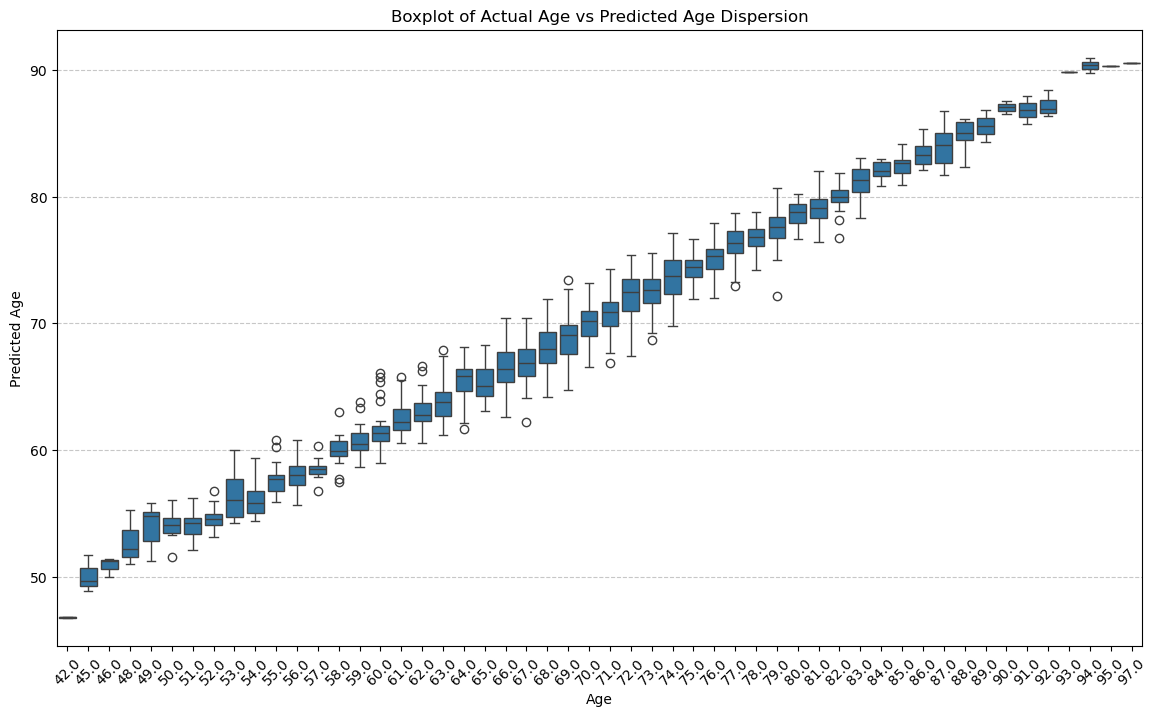

In [66]:
print(metrics_full[0].shape)
print(metrics_full[1].shape)
plot_age_prediction_boxplot(metrics_full[0], metrics_full[1])

### Submission Ready Example

Same as before but training on the full dataset

In [ ]:
metrics_full= run_pipeline(
    imputer_name='KNN',
    outlierDetetor='PCAGaussian',
    feature_selector_names=['TreeBased', 'Lasso'],
    model_name='XGBoostEnsemble',
    submission_filename='submission_baseline.csv',
    train_full=False,
    split_seed=1
)
print(metrics_full)


=== Running Pipeline with:
Imputer: KNN
Feature Selector: ['TreeBased', 'Lasso']
Model: XGBoostEnsemble
Train on full dataset: False ===

Fitting imputer on combined data


/nix/store/bj5dqnlwb7501kj17lsisa4cns79y6ss-python3.11-scikit-learn-1.4.2/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNNImputer was fitted without feature names
  warnings.warn(
/nix/store/bj5dqnlwb7501kj17lsisa4cns79y6ss-python3.11-scikit-learn-1.4.2/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNNImputer was fitted without feature names
  warnings.warn(


Imputation completed.
Number of outliers detected: 67
(1212, 1)
(1145, 1)
Outlier removal completed. Number of inliers: 1145
Scaling completed.


/nix/store/bj5dqnlwb7501kj17lsisa4cns79y6ss-python3.11-scikit-learn-1.4.2/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Feature selection completed. Number of selected features: 387
Performing train-validation split and training XGBoostEnsemble.
Training model 1/5 in ensemble
Training model 2/5 in ensemble
Training model 3/5 in ensemble
Training model 4/5 in ensemble
Training model 5/5 in ensemble
Validation R^2 Score: 0.6387, MAE: 4.2320, MSE: 27.7307
Submission saved to submission_baseline.csv
{'Imputer': 'KNN', 'Feature Selector': ['TreeBased', 'Lasso'], 'Model': 'XGBoostEnsemble', 'Validation R2': 0.6386563640752599, 'Validation MAE': 4.231969291986857, 'Validation MSE': 27.73067965961803}


In [32]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_age_prediction_boxplot(ages, predictions):
    """
    Function to create a boxplot of actual ages vs predicted ages.
    
    Parameters:
    ages (list or numpy array): Array of actual ages.
    predictions (list or numpy array): Array of predicted ages.
    
    Returns:
    None: Displays the boxplot.
    """
    # Convert inputs to numpy arrays if they aren't already
    ages = np.array(ages)
    predictions = np.array(predictions)

    # Get unique ages
    unique_ages = np.unique(ages)

    # Create lists for boxplot representation
    ages_list = []
    prediction_values = []

    for age in unique_ages:
        # Get all predictions corresponding to the current age
        age_predictions = predictions[ages == age]
        
        # Append the age multiple times for boxplotting
        ages_list.extend([age] * len(age_predictions))
        prediction_values.extend(age_predictions)

    # Plotting the boxplot
    plt.figure(figsize=(14, 8))
    sns.boxplot(x=ages_list, y=prediction_values)
    plt.xlabel('Age')
    plt.ylabel('Predicted Age')
    plt.title('Boxplot of Actual Age vs Predicted Age Dispersion')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


## Inspect Features Selection


In [ ]:

def features_selection(imputer_name, feature_selector_name ,scaleBefore=False):
    print(f"Feature Selector: {feature_selector_name}")
    
    # Step 1: Imputation
    imputer = imputers[imputer_name]

    if imputer_name == 'KNN':
        imputer.fit(X_train, X_test) # fitting the KNN imputer on both train and test data, showed very slight performance increase
    else:
        imputer.fit(X_train)
    X_train_imputed_values = imputer.transform(X_train)
    x_c = X_train_full.copy()
    x_c[features] = X_train_imputed_values
    
    X_test_imputed_values = imputer.transform(X_test)
    x_test_c = X_test_full.copy()
    x_test_c[features] = X_test_imputed_values
    print("Imputation completed.")

    if  scaleBefore:
        scaler = StandardScaler()
        x_c = scaler.fit_transform(x_c)
        x_test_c = scaler.transform(x_test_c)
        print("Scaling completed.")
        y_scaler = StandardScaler()
        y_c = y_scaler.fit_transform(y_train)
    
    # Step 2: Outlier Detection and Removal
    outlier_detector = OutlierDetector(n_components=2)
    outlier_detector.fit(x_c[features].values, plot=True)
    x_c = outlier_detector.transform(x_c)
    y_c = y_train_full['y'].values[outlier_detector.get_inlier_mask()]
    print(f"Outlier removal completed. Number of inliers: {len(y_c)}")

    
    # Step 3: Feature Selection
    feature_selector = feature_selectors[feature_selector_name]
    feature_selector.fit(x_c, y_c)
    x_c = feature_selector.transform(x_c)
    x_test_c = feature_selector.transform(x_test_c)
    selected_features = features[feature_selector.get_support()]
    print(f"Feature selection completed. Number of selected features: {x_c.shape[1]}")
    return selected_features



Feature Selector: VarianceThreshold
Fitting imputer on combined data
Imputation completed.


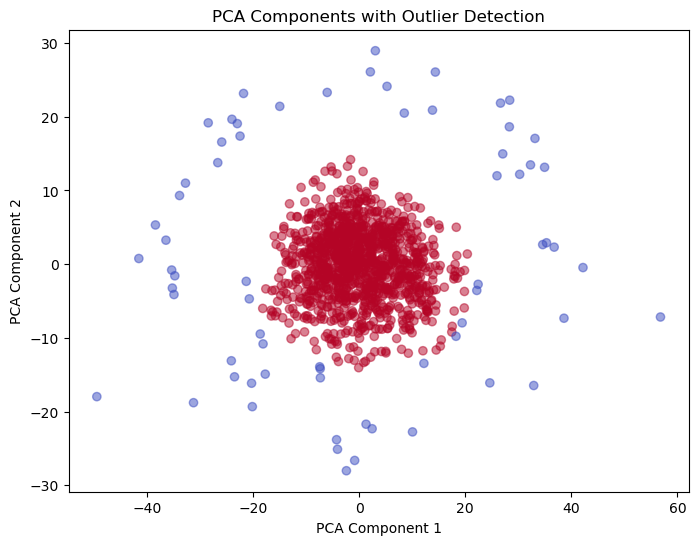

Number of outliers detected: 67
Outlier removal completed. Number of inliers: 1145


IndexError: boolean index did not match indexed array along dimension 0; dimension is 832 but corresponding boolean dimension is 833

In [ ]:
out ={}
for key in feature_selectors.keys():
    out[key]=features_selection('KNN', key)
    print("=====================================================")
print(out)

In [ ]:

for key in out.keys():
    print(f"Feature Selector: {key}")
    print(len(out[key]))
    print(out[key])

Feature Selector: VarianceThreshold
828
Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9',
       ...
       'x822', 'x823', 'x824', 'x825', 'x826', 'x827', 'x828', 'x829', 'x830',
       'x831'],
      dtype='object', length=828)
Feature Selector: Univariate
10
Index(['x133', 'x159', 'x194', 'x334', 'x415', 'x458', 'x465', 'x485', 'x507',
       'x702'],
      dtype='object')
Feature Selector: Lasso
607
Index(['x0', 'x1', 'x2', 'x3', 'x5', 'x6', 'x7', 'x8', 'x10', 'x11',
       ...
       'x821', 'x822', 'x823', 'x824', 'x825', 'x826', 'x827', 'x829', 'x830',
       'x831'],
      dtype='object', length=607)
Feature Selector: TreeBased
78
Index(['x15', 'x18', 'x27', 'x29', 'x42', 'x87', 'x92', 'x113', 'x115', 'x132',
       'x133', 'x159', 'x172', 'x193', 'x194', 'x200', 'x209', 'x231', 'x232',
       'x242', 'x247', 'x254', 'x263', 'x286', 'x306', 'x309', 'x310', 'x312',
       'x320', 'x325', 'x327', 'x334', 'x342', 'x345', 'x349', 'x362', 'x383',
       'x402', 'x41